# Load Lib

In [ ]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import os, shutil, kagglehub

split_ratios = {
    '90:10': 0.1,
    '80:20': 0.2,
    '70:30': 0.3
}

models = {
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


# DATASET UNSW-NB15

## LOAD DATASET

In [ ]:
train_df = pd.read_csv('/content/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('/content/UNSW_NB15_testing-set.csv')
df = pd.concat([train_df, test_df], axis=0)
df.drop(columns=['id'], inplace=True, errors='ignore')

## PREPROCESSING

### MISSING VALUE

In [ ]:
print("--- Before handling missing values (UNSW-NB15) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_before = df.copy()

df.dropna(inplace=True)

print("\n--- After handling missing values (UNSW-NB15) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Display 2 tabel before & after
print("\n=== BEFORE (with missing values) ===")
display(df_before.head(10).style.highlight_null(color='salmon').set_caption("Before dropna - UNSW-NB15"))

print("\n=== AFTER (missing values removed) ===")
display(df.head(10).style.set_caption("After dropna - UNSW-NB15"))

--- Before handling missing values (UNSW-NB15) ---
Shape: (257673, 44)
Missing values per column:
Series([], dtype: int64)

--- After handling missing values (UNSW-NB15) ---
Shape: (257673, 44)
Missing values per column:
Series([], dtype: int64)


### ENCODING (categorical → numeric)

In [ ]:

# ==============================
# ENCODING (categorical → numeric)
# ==============================
categorical_cols = ['proto', 'service', 'state']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("5 baris pertama dari hasil encoding:")
display(df.head(5))

5 baris pertama dari hasil encoding:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,119,0,5,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,119,0,5,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,119,0,5,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,119,0,5,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,119,0,5,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


## SPLIT FEATURE, LABEL, AND TRAIN MODEL


--- Before Normalization (UNSW-NB15) ---
First 5 rows of X (features):


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,119,0,5,2,0,496,0,90909.0902,254,...,1,1,1,2,0,0,0,1,2,0
1,0.000008,119,0,5,2,0,1762,0,125000.0003,254,...,1,1,1,2,0,0,0,1,2,0
2,0.000005,119,0,5,2,0,1068,0,200000.0051,254,...,1,1,1,3,0,0,0,1,3,0
3,0.000006,119,0,5,2,0,900,0,166666.6608,254,...,2,2,1,3,0,0,0,2,3,0
4,0.000010,119,0,5,2,0,2126,0,100000.0025,254,...,2,2,1,3,0,0,0,2,3,0



Descriptive statistics of X (features) before normalization:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
count,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,1.246715,110.136025,1.555902,4.341468,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,...,6.050467,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274
std,5.974305,21.349900,2.245945,0.887420,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,...,8.173749,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000008,113.000000,0.000000,4.000000,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.004285,113.000000,0.000000,4.000000,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,...,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000
75%,0.685777,119.000000,2.000000,5.000000,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,...,6.000000,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000
max,59.999989,132.000000,12.000000,10.000000,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,...,59.000000,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000



--- After Normalization (UNSW-NB15) ---
First 5 rows of X (features) after normalization:


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,1.833334e-07,0.901515,0.0,0.5,0.000094,0.0,0.000033,0.0,0.090909,0.996078,...,0.000000,0.000000,0.0,0.015625,0.0,0.0,0.0,0.000000,0.016393,0.0
1,1.333334e-07,0.901515,0.0,0.5,0.000094,0.0,0.000121,0.0,0.125000,0.996078,...,0.000000,0.000000,0.0,0.015625,0.0,0.0,0.0,0.000000,0.016393,0.0
2,8.333335e-08,0.901515,0.0,0.5,0.000094,0.0,0.000073,0.0,0.200000,0.996078,...,0.000000,0.000000,0.0,0.031250,0.0,0.0,0.0,0.000000,0.032787,0.0
3,1.000000e-07,0.901515,0.0,0.5,0.000094,0.0,0.000061,0.0,0.166667,0.996078,...,0.017241,0.017241,0.0,0.031250,0.0,0.0,0.0,0.016949,0.032787,0.0
4,1.666667e-07,0.901515,0.0,0.5,0.000094,0.0,0.000146,0.0,0.100000,0.996078,...,0.017241,0.017241,0.0,0.031250,0.0,0.0,0.0,0.016949,0.032787,0.0



--- Split 90:10 ---

Model: KNN


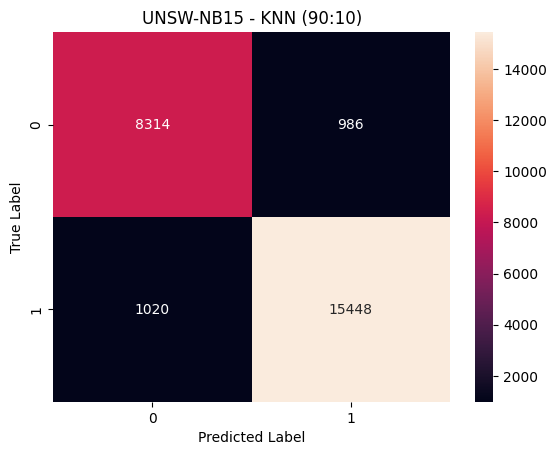

Accuracy : 0.9221515057435579
Precision: 0.9222165294804321
Recall   : 0.9221515057435579
F1 Score : 0.9221823045473966
Time: 49.080668449401855

Model: Random Forest


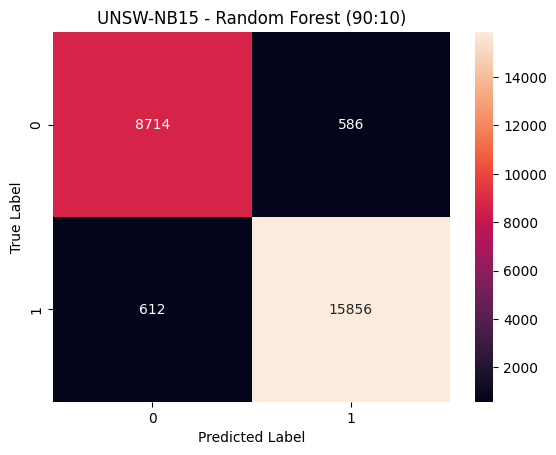

Accuracy : 0.9535082272586153
Precision: 0.9535384797604709
Recall   : 0.9535082272586153
F1 Score : 0.9535223111225012
Time: 82.81026005744934

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:12:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


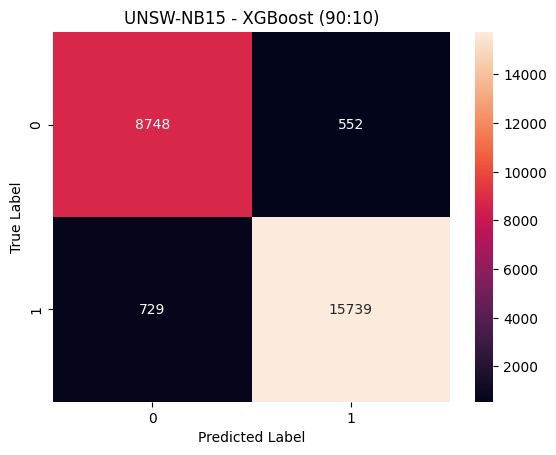

Accuracy : 0.9502871778950637
Precision: 0.9505828144491617
Recall   : 0.9502871778950637
F1 Score : 0.9503871834546066
Time: 4.120337724685669

--- Split 80:20 ---

Model: KNN


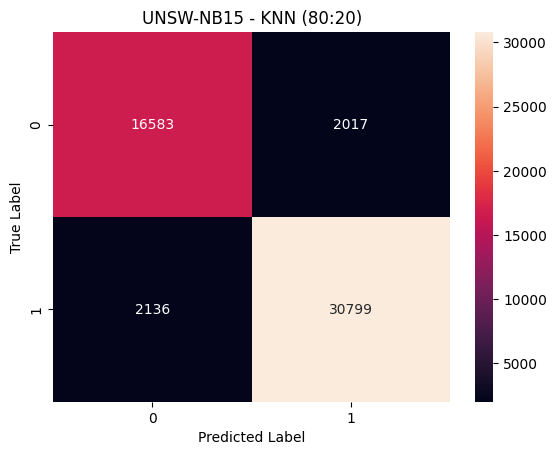

Accuracy : 0.9194139904918988
Precision: 0.9195355530030812
Recall   : 0.9194139904918988
F1 Score : 0.9194695491396301
Time: 90.30733180046082

Model: Random Forest


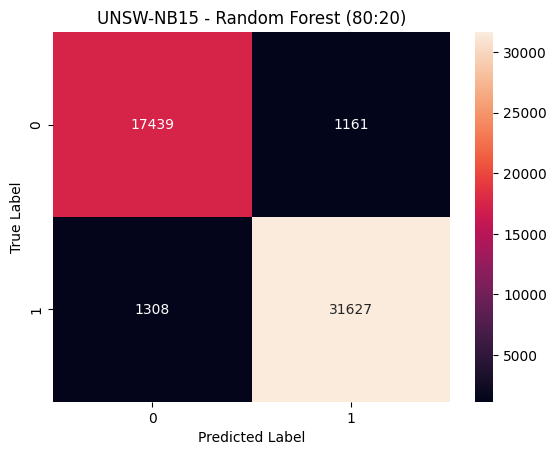

Accuracy : 0.9520908120694673
Precision: 0.9521888269039183
Recall   : 0.9520908120694673
F1 Score : 0.952131520487289
Time: 74.76201939582825

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


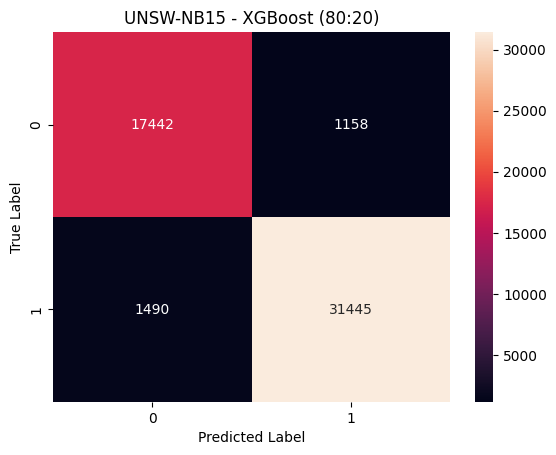

Accuracy : 0.9486174444552246
Precision: 0.9488956488057371
Recall   : 0.9486174444552246
F1 Score : 0.9487145580390125
Time: 3.872572898864746

--- Split 70:30 ---

Model: KNN


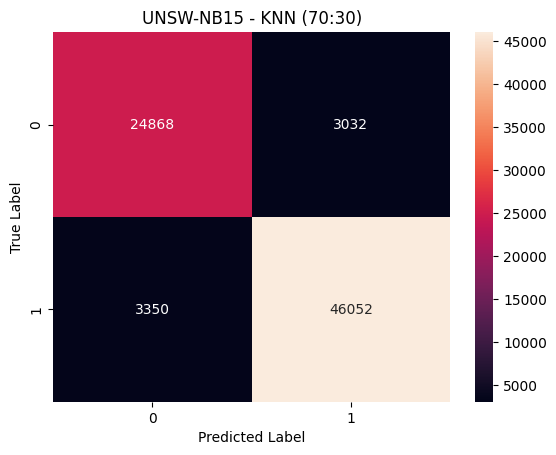

Accuracy : 0.9174406871749761
Precision: 0.9176749516384859
Recall   : 0.9174406871749761
F1 Score : 0.9175413164800449
Time: 110.59489321708679

Model: Random Forest


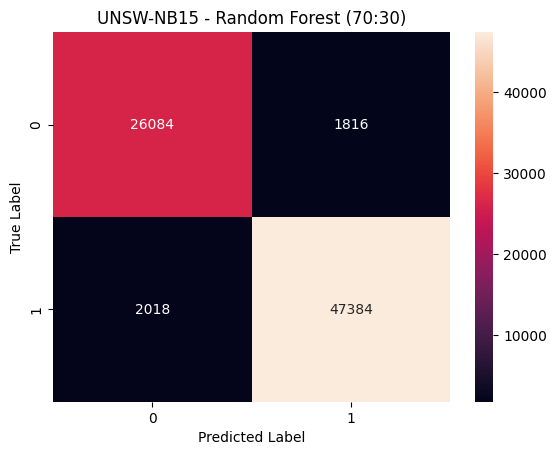

Accuracy : 0.9504023181806421
Precision: 0.9504935144217694
Recall   : 0.9504023181806421
F1 Score : 0.9504409640507411
Time: 60.44166588783264

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


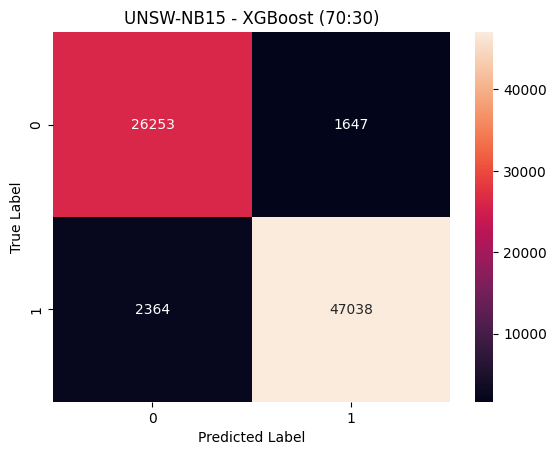

Accuracy : 0.9481125973454761
Precision: 0.9485650332143164
Recall   : 0.9481125973454761
F1 Score : 0.9482520865390432
Time: 3.368488311767578


In [ ]:
# ==============================
# SPLIT FEATURE & LABEL
# ==============================
X = df.drop(columns=['label', 'attack_cat'])
y = df['label']

print("\n--- Before Normalization (UNSW-NB15) ---")
print("First 5 rows of X (features):")
display(pd.DataFrame(X).head())
print("\nDescriptive statistics of X (features) before normalization:")
display(pd.DataFrame(X).describe())

# ==============================
# NORMALISASI
# ==============================
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

print("\n--- After Normalization (UNSW-NB15) ---")
print("First 5 rows of X (features) after normalization:")
display(pd.DataFrame(X).head())
# Removed descriptive statistics after normalization as requested.

for split_name, test_size in split_ratios.items():
    print(f'\n--- Split {split_name} ---')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    for name, model in models.items():
        print(f'\nModel: {name}')
        start = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        end = time.time()

        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'UNSW-NB15 - {name} ({split_name})')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("Accuracy :", accuracy)
        print("Precision:", precision)
        print("Recall   :", recall)
        print("F1 Score :", f1)
        print('Time:', end-start)

# DATASET NSL-KDD

## LOAD DATASET

In [ ]:
train_df = pd.read_csv("Train_data.csv", delimiter=';')
test_df = pd.read_csv("Test_data.csv", delimiter=';')
df = pd.concat([train_df, test_df], axis=0)

## PREPROCESSING

### MISSING VALUE

In [ ]:
print("--- Before handling missing values (NSL-KDD) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_before = df.copy()

df.dropna(inplace=True)

print("\n--- After handling missing values (NSL-KDD) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Display 2 tabel before & after
print("\n=== BEFORE (with missing values) ===")
display(df_before.head(10).style.highlight_null(color='salmon').set_caption("Before dropna"))

print("\n=== AFTER (missing values removed) ===")
display(df.head(10).style.set_caption("After dropna"))

--- Before handling missing values (NSL-KDD) ---
Shape: (47736, 42)
Missing Values:
class    22544
dtype: int64

--- After handling missing values (NSL-KDD) ---
Shape: (25192, 42)
Missing Values:
Series([], dtype: int64)


### ENCODING (categorical → numeric)

In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag', 'class']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode the 'class' column
df['class'] = le.fit_transform(df['class'])
print("5 baris pertama dari hasil encoding:")
display(df.head(5))

5 baris pertama dari hasil encoding:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,19,9,491,0,0,0,0,0,...,25,00.17,00.03,00.17,0,0,0,00.05,0,1
1,0,2,41,9,146,0,0,0,0,0,...,1,0,00.06,"0,061111111",0,0,0,0,0,1
2,0,1,46,5,0,0,0,0,0,0,...,26,00.01,00.05,0,0,1,1,0,0,0
3,0,1,22,9,232,8153,0,0,0,0,...,255,1,0,00.03,00.04,00.03,00.01,0,00.01,1
4,0,1,22,9,199,420,0,0,0,0,...,255,1,0,0,0,0,0,0,0,1


## SPLIT FEATURE, LABEL, AND TRAIN MODEL


--- Before Normalization (NSL-KDD) ---
First 5 rows of X (features):


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,19,9,491,0,0,0,0,0,...,150,25,0.17,0.03,0.170000,0.00,0.00,0.00,0.05,0.00
1,0,2,41,9,146,0,0,0,0,0,...,255,1,0.00,0.06,0.061111,0.00,0.00,0.00,0.00,0.00
2,0,1,46,5,0,0,0,0,0,0,...,255,26,0.01,0.05,0.000000,0.00,1.00,1.00,0.00,0.00
3,0,1,22,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.030000,0.04,0.03,0.01,0.00,0.01
4,0,1,22,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.000000,0.00,0.00,0.00,0.00,0.00



Descriptive statistics of X (features) before normalization:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,25192.000000,25192.000000,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,1.053827,29.039139,6.982455,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,...,182.532074,115.063036,0.439705,0.058387,0.114074,0.024599,0.273787,0.274742,0.093273,0.107740
std,2686.555640,0.426998,15.555601,2.679322,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,...,98.993895,110.646850,0.454939,0.140171,0.276998,0.093596,0.440435,0.444292,0.277235,0.305365
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,19.000000,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,84.000000,10.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,22.000000,9.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,255.000000,61.000000,0.090000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,46.000000,9.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.046528,0.010000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,2.000000,65.000000,10.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- After Normalization (NSL-KDD) ---
First 5 rows of X (features) after normalization:


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.0,0.5,0.292308,0.9,1.286320e-06,0.000000,0.0,0.0,0.0,0.0,...,0.588235,0.098039,0.17,0.03,0.170000,0.00,0.00,0.00,0.05,0.00
1,0.0,1.0,0.630769,0.9,3.824902e-07,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.003922,0.00,0.06,0.061111,0.00,0.00,0.00,0.00,0.00
2,0.0,0.5,0.707692,0.5,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.101961,0.01,0.05,0.000000,0.00,1.00,1.00,0.00,0.00
3,0.0,0.5,0.338462,0.9,6.077927e-07,0.001583,0.0,0.0,0.0,0.0,...,0.117647,1.000000,1.00,0.00,0.030000,0.04,0.03,0.01,0.00,0.01
4,0.0,0.5,0.338462,0.9,5.213394e-07,0.000082,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.00,0.00,0.000000,0.00,0.00,0.00,0.00,0.00



--- Split 90:10 ---

Model: KNN


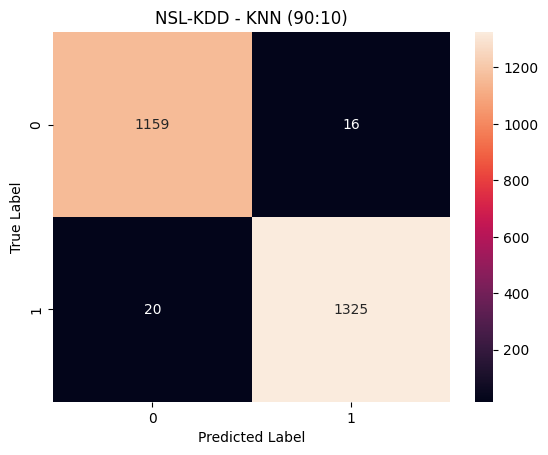

Accuracy : 0.9857142857142858
Precision: 0.9857222732284638
Recall   : 0.9857142857142858
F1 Score : 0.985715785943342
Time: 0.40381526947021484

Model: Random Forest


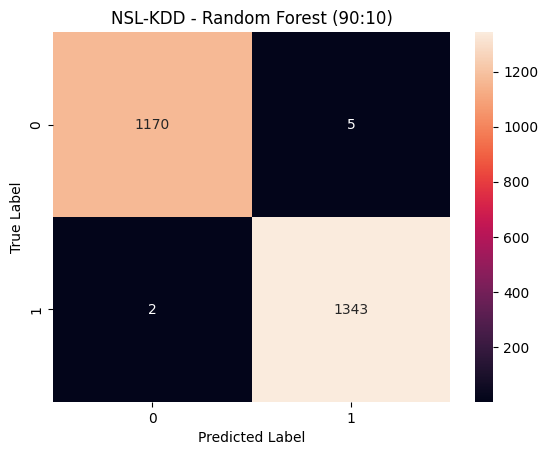

Accuracy : 0.9972222222222222
Precision: 0.9972246064057597
Recall   : 0.9972222222222222
F1 Score : 0.9972219941274066
Time: 1.7634940147399902

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


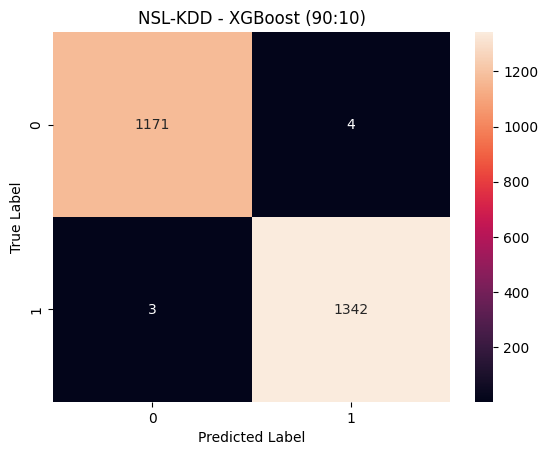

Accuracy : 0.9972222222222222
Precision: 0.9972223874610845
Recall   : 0.9972222222222222
F1 Score : 0.9972221470777749
Time: 0.5073463916778564

--- Split 80:20 ---

Model: KNN


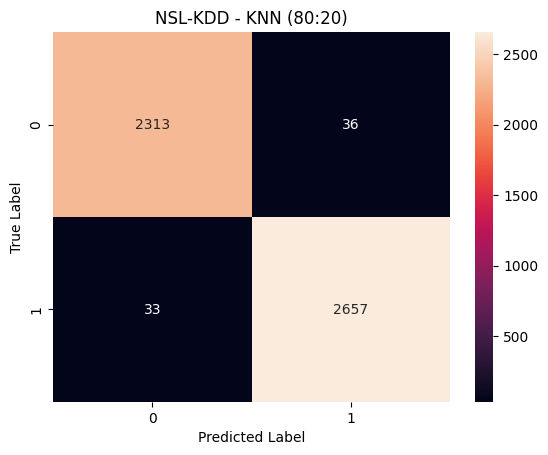

Accuracy : 0.9863068069061321
Precision: 0.9863063910467897
Recall   : 0.9863068069061321
F1 Score : 0.9863062477611225
Time: 1.2858319282531738

Model: Random Forest


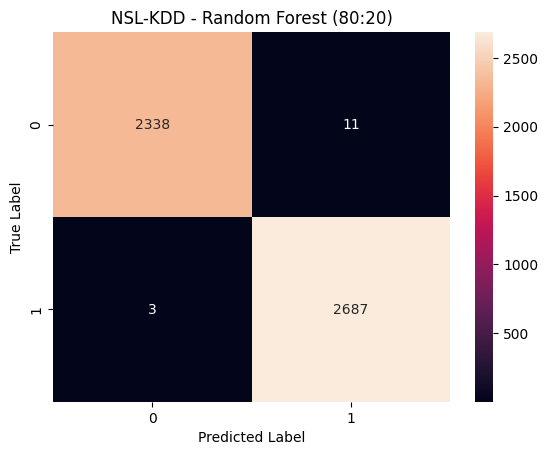

Accuracy : 0.9972216709664616
Precision: 0.9972261092923405
Recall   : 0.9972216709664616
F1 Score : 0.997221363994534
Time: 2.241419553756714

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


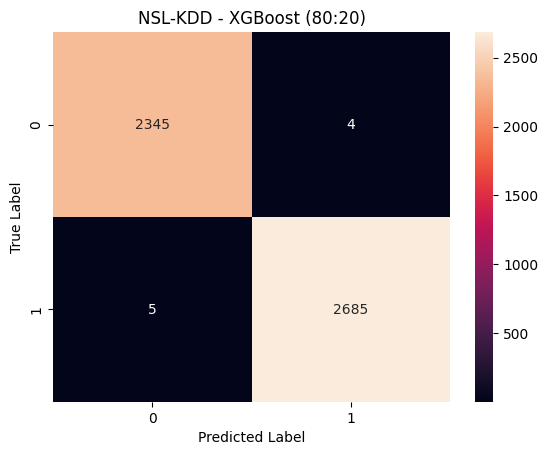

Accuracy : 0.9982139313355824
Precision: 0.9982140583682748
Recall   : 0.9982139313355824
F1 Score : 0.9982139553609523
Time: 0.4486093521118164

--- Split 70:30 ---

Model: KNN


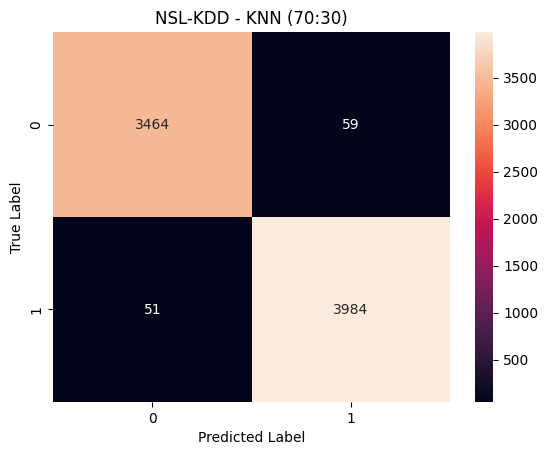

Accuracy : 0.9854458851548028
Precision: 0.9854459739378986
Recall   : 0.9854458851548028
F1 Score : 0.9854448202126522
Time: 0.953514575958252

Model: Random Forest


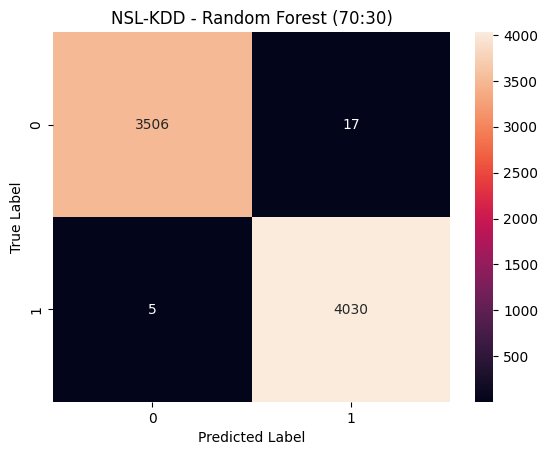

Accuracy : 0.9970891770309606
Precision: 0.9970935854142662
Recall   : 0.9970891770309606
F1 Score : 0.9970888550671074
Time: 1.4040942192077637

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


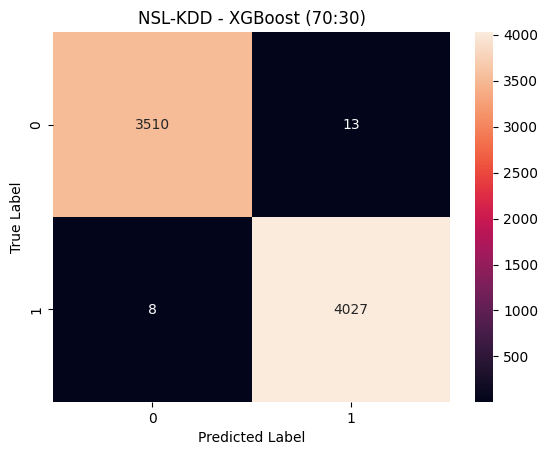

Accuracy : 0.997221487165917
Precision: 0.9972221115390666
Recall   : 0.997221487165917
F1 Score : 0.9972213608389471
Time: 0.4119706153869629


In [ ]:
# Convert all object columns (which may contain comma decimals) to numeric
for col in df.columns:
    if df[col].dtype == 'object':
        # Replace comma with dot for decimal separator
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values that might have been introduced by failed conversion
df.dropna(inplace=True)

X = df.drop(columns=['class'])
y = df['class']

print("\n--- Before Normalization (NSL-KDD) ---")
print("First 5 rows of X (features):")
display(pd.DataFrame(X).head())
print("\nDescriptive statistics of X (features) before normalization:")
display(pd.DataFrame(X).describe())

# ==============================
# NORMALISASI
# ==============================
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

print("\n--- After Normalization (NSL-KDD) ---")
print("First 5 rows of X (features) after normalization:")
display(pd.DataFrame(X).head())
# Removed descriptive statistics after normalization as requested.

for split_name, test_size in split_ratios.items():
    print(f'\n--- Split {split_name} ---')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    for name, model in models.items():
        print(f'\nModel: {name}')
        start = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        end = time.time()

        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'NSL-KDD - {name} ({split_name})')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("Accuracy :", accuracy)
        print("Precision:", precision)
        print("Recall   :", recall)
        print("F1 Score :", f1)
        print('Time:', end-start)

# DATASET CICIDS 2019

## LOAD DATASET

In [ ]:
DATA_PATH = '/content/syn_data.csv'

if not os.path.exists(DATA_PATH):
    print('Downloading dataset...')
    path = kagglehub.dataset_download('tarundhamor/cicids-2019-dataset')
    src = os.path.join(path, 'syn_data.csv')
    shutil.copy(src, DATA_PATH)

df = pd.read_csv(DATA_PATH, low_memory=False)


## PREPROCESSING

### MISSING VALUE

In [ ]:
print("--- Before handling missing values (CICIDS 2019) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_before = df.copy()

df.dropna(inplace=True)

print("\n--- After handling missing values (CICIDS 2019) ---")
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Display 2 tabel before & after
print("\n=== BEFORE (with missing values) ===")
display(df_before.head(10).style.highlight_null(color='salmon').set_caption("Before dropna - CICIDS 2019"))

print("\n=== AFTER (missing values removed) ===")
display(df.head(10).style.set_caption("After dropna - CICIDS 2019"))

--- Before handling missing values (CICIDS 2019) ---
Shape: (1582681, 88)
Missing Values:
Flow Bytes/s    202277
dtype: int64

--- After handling missing values (CICIDS 2019) ---
Shape: (1380404, 88)
Missing Values:
Series([], dtype: int64)


### ENCODING

In [ ]:
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print("5 baris pertama dari hasil encoding:")
display(df['Label'].head(5))

5 baris pertama dari hasil encoding:


,Label
0,1
1,1
2,1
3,1
4,1


## SPLIT FEATURE, LABEL, AND TRAIN MODEL


--- Before Normalization (CICIDS 2019) ---
First 5 rows of X (features):


,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
0,281052,53058,53058,6,115799309,19,2,0.0,0.0,0.0,...,20,244280.142857,646237.483665,1709809.0,1.0,1.426117e+07,3.220326e+06,21714933.0,11043464.0,1
1,450424,32237,32237,6,113973933,16,0,0.0,0.0,0.0,...,20,9.000000,19.595918,49.0,1.0,1.628198e+07,2.573891e+06,20019405.0,11993631.0,1
2,182979,60495,9840,6,112,2,2,0.0,0.0,0.0,...,20,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,1
3,41540,59724,59724,6,105985004,16,0,0.0,0.0,0.0,...,20,7.857143,17.705259,48.0,1.0,1.514071e+07,3.077366e+06,20954123.0,11120336.0,1
4,358711,60496,32538,6,1,2,0,0.0,0.0,0.0,...,20,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,1



Descriptive statistics of X (features) before normalization:


,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
count,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,...,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06,1.380364e+06
mean,3.958528e+05,3.664299e+04,3.280797e+04,6.005515e+00,9.271872e+06,3.126435e+00,3.530069e-01,4.978187e-01,2.436086e+00,1.679434e-01,...,2.000084e+01,2.529128e+03,5.284907e+03,1.173787e+04,5.893139e+01,1.726524e+06,6.137633e+05,2.625131e+06,1.116830e+06,9.996573e-01
std,2.286729e+05,1.872822e+04,1.891081e+04,2.475924e-01,2.869732e+07,6.371310e+00,1.226963e+00,6.223200e+01,1.359335e+03,1.327930e+01,...,1.194973e-01,4.466557e+04,8.818169e+04,1.927736e+05,1.200803e+04,5.458329e+06,2.256995e+06,8.449847e+06,3.629755e+06,1.850800e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.979328e+05,2.047000e+04,1.645400e+04,6.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,3.957800e+05,3.687700e+04,3.284000e+04,6.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,5.937080e+05,5.368700e+04,4.917100e+04,6.000000e+00,4.900000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,8.052440e+05,6.553200e+04,6.553500e+04,1.700000e+01,1.199997e+08,4.478000e+03,8.170000e+02,3.373800e+04,1.468048e+06,2.847000e+03,...,4.000000e+01,6.775650e+06,5.942732e+06,8.834899e+06,6.775650e+06,1.151661e+08,5.727195e+07,1.151661e+08,1.151661e+08,1.000000e+00



--- After Normalization (CICIDS 2019) ---
First 5 rows of X (features) after normalization:


,0,1,2,3,4,5,6,7,8,9,...,72,73,74,75,76,77,78,79,80,81
0,0.349027,0.809650,0.809613,0.352941,9.649970e-01,0.004021,0.002448,0.0,0.0,0.0,...,0.5,0.036053,0.108744,0.193529,1.475873e-07,0.123831,0.056229,0.188553,0.095892,1.0
1,0.559363,0.491928,0.491905,0.352941,9.497855e-01,0.003350,0.000000,0.0,0.0,0.0,...,0.5,0.000001,0.000003,0.000006,1.475873e-07,0.141378,0.044942,0.173831,0.104142,1.0
2,0.227234,0.923137,0.150149,0.352941,9.250027e-07,0.000223,0.002448,0.0,0.0,0.0,...,0.5,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.0
3,0.051587,0.911372,0.911330,0.352941,8.832109e-01,0.003350,0.000000,0.0,0.0,0.0,...,0.5,0.000001,0.000003,0.000005,1.475873e-07,0.131468,0.053733,0.181947,0.096559,1.0
4,0.445469,0.923152,0.496498,0.352941,0.000000e+00,0.000223,0.000000,0.0,0.0,0.0,...,0.5,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.0



--- Split 90:10 ---

Model: KNN


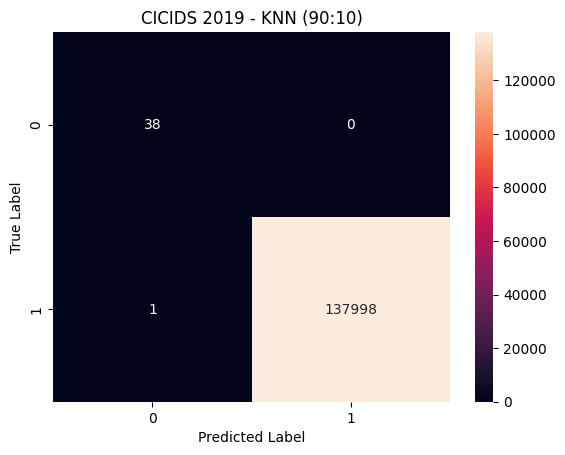

Accuracy : 0.9999927555655368
Precision: 0.9999929413202667
Recall   : 0.9999927555655368
F1 Score : 0.999992802594195
Time: 1779.4940707683563

Model: Random Forest


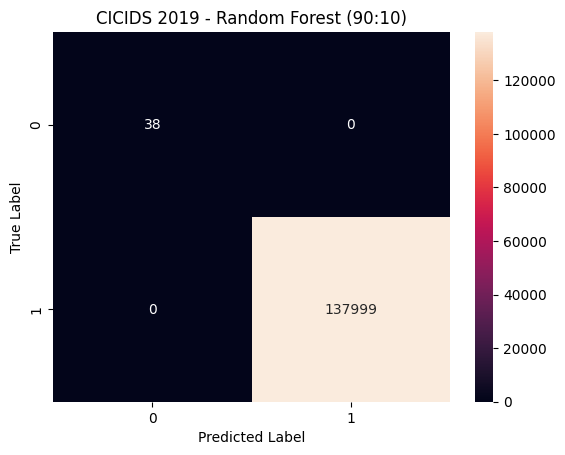

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Time: 349.44833183288574

Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:55:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


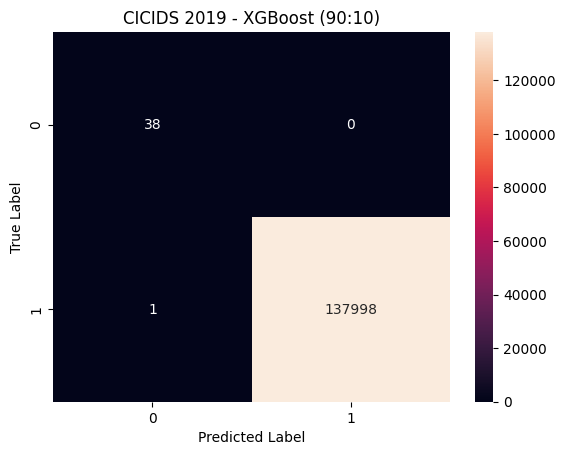

Accuracy : 0.9999927555655368
Precision: 0.9999929413202667
Recall   : 0.9999927555655368
F1 Score : 0.999992802594195
Time: 29.984909772872925

--- Split 80:20 ---

Model: KNN


In [ ]:
# ==============================
# 6. FEATURE & TARGET
# ==============================
X = df.drop(columns=['Label'])
y = df['Label']

# Ambil hanya numeric (penting karena ada mixed type)
X = X.select_dtypes(include=[np.number])
feature_names = X.columns

# Handle infinite values: replace with NaN and then drop rows with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)

# Pastikan y juga di-filter sesuai dengan X yang sudah di-dropna
# Karena X.dropna() bisa mengurangi baris, kita perlu memastikan y juga sinkron.
# Kita akan mendapatkan indeks dari X yang sudah bersih.
clean_indices = X.index
y = y.loc[clean_indices]

print("\n--- Before Normalization (CICIDS 2019) ---")
print("First 5 rows of X (features):")
display(pd.DataFrame(X).head())
print("\nDescriptive statistics of X (features) before normalization:")
display(pd.DataFrame(X).describe())

# ==============================
# 7. NORMALISASI
# ==============================
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

print("\n--- After Normalization (CICIDS 2019) ---")
print("First 5 rows of X (features) after normalization:")
display(pd.DataFrame(X, columns=feature_names).head())
# Removed descriptive statistics after normalization as requested.

for split_name, test_size in split_ratios.items():
    print(f'\n--- Split {split_name} ---')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    for name, model in models.items():
        print(f'\nModel: {name}')
        start = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        end = time.time()

        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'CICIDS 2019 - {name} ({split_name})')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("Accuracy :", accuracy)
        print("Precision:", precision)
        print("Recall   :", recall)
        print("F1 Score :", f1)
        print('Time:', end-start)

```markdown
# Simulasi Implementasi Web App (Streamlit)

Berikut adalah contoh bagaimana Anda bisa menyimpan model yang telah dilatih dan memuatnya kembali untuk digunakan dalam aplikasi web. Biasanya, file `app.py` akan dipisahkan dari notebook pelatihan.
```

In [ ]:
import joblib

# Contoh: Menyimpan salah satu model yang sudah dilatih (misal: Random Forest dari loop terakhir)
# Pastikan cell pelatihan sebelumnya sudah dijalankan
try:
    joblib.dump(models['Random Forest'], 'model_rf_cicids.pkl')
    joblib.dump(scaler, 'scaler_cicids.pkl')
    print("Model dan Scaler berhasil disimpan untuk aplikasi web!")
except Exception as e:
    print(f"Gagal menyimpan model: {e}. Pastikan Anda telah menjalankan proses training terlebih dahulu.")